# Monocle Tutorial

This notebook analyzes the data presented in [Paul et al. 2015, "Transcriptional Heterogeneity and Lineage Commitment in Myeloid Progenitors"](https://doi.org/10.1016/j.cell.2015.11.013) and made available via [Scanpy](https://scanpy.readthedocs.io/en/1.10.x/index.html). The steps included here are intended to mirror those in the PAGA notebook included in this repository; if you are unfamiliar with single-cell processing, we recommend starting there.

In [12]:
h5_file <- "paul15.h5"

## Preamble: Install and import packages

In [13]:
install.packages("BiocManager")
BiocManager::install(c('BiocGenerics', 'DelayedArray', 'DelayedMatrixStats',
                       'limma', 'lme4', 'S4Vectors', 'SingleCellExperiment',
                       'SummarizedExperiment', 'batchelor', 'HDF5Array',
                       'terra', 'ggrastr'))
install.packages("devtools")
devtools::install_github('cole-trapnell-lab/monocle3')
install.packages("hdf5r")
install.packages('svglite')

package 'BiocManager' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\HuttonA2\AppData\Local\Temp\RtmpMhulGL\downloaded_packages


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'BiocGenerics' 'DelayedArray'
  'DelayedMatrixStats' 'limma' 'lme4' 'S4Vectors' 'SingleCellExperiment'
  'SummarizedExperiment' 'batchelor' 'HDF5Array' 'terra' 'ggrastr'"
Old packages: 'class', 'cluster', 'foreign', 'KernSmooth', 'MASS', 'Matrix',
  'nlme', 'nnet', 'rpart', 'spatial', 'survival'



package 'devtools' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\HuttonA2\AppData\Local\Temp\RtmpMhulGL\downloaded_packages


Skipping install of 'monocle3' from a github remote, the SHA1 (98402ed0) has not changed since last install.
  Use `force = TRUE` to force installation

Warning message:
"package 'hdf5r' is in use and will not be installed"


package 'svglite' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\HuttonA2\AppData\Local\Temp\RtmpMhulGL\downloaded_packages


In [14]:
# remotes::install_github("satijalab/seurat", "seurat5", quiet = TRUE)

In [15]:
library(hdf5r)
library(monocle3)
library(dplyr)
library(ggplot2)
library(Matrix)
library(RColorBrewer)

In [16]:
library(dplyr)
library(ggplot2)
library(Matrix)
library(RColorBrewer)


### Data load

In [17]:
# Load .h5 file; 
h5 <- H5File$new(h5_file, mode="r")
print(h5)

# Extract datasets to make Monocle Cell Data Set
data <- h5[["data"]][, ]
rownames <- h5[["data_rownames"]][]
colnames <- h5[["data_colnames"]][]
cluster_id <- h5[["cluster.id"]][, ]

Class: H5File
Filename: C:\Users\HuttonA2\OneDrive - Cedars-Sinai Health System\stuff\Downloads\paul15.h5
Access type: H5F_ACC_RDONLY
Listing:
                    name    obj_type dataset.dims dataset.type_class
          data.debatched H5I_DATASET  2730 x 8716          H5T_FLOAT
              cluster.id H5I_DATASET     1 x 2730          H5T_FLOAT
             batch.names H5I_DATASET     1 x 2730        H5T_INTEGER
 data.debatched_colnames H5I_DATASET         2730         H5T_STRING
    batch.names_rownames H5I_DATASET         2730         H5T_STRING
      info.genes_strings H5I_DATASET         3461         H5T_STRING
 data.debatched_rownames H5I_DATASET         8716         H5T_STRING
                    data H5I_DATASET  2730 x 8716        H5T_INTEGER
           data_rownames H5I_DATASET         8716         H5T_STRING
           data_colnames H5I_DATASET         2730         H5T_STRING
< Printed 10, out of 11>


In [18]:
# Format datasets
sparse_matrix <- Matrix(data, sparse=TRUE)
cell_metadata <- data.frame(cell_id=colnames, data_cluster=cluster_id, row.names=colnames)
gene_metadata <- data.frame(gene_id=rownames, gene_short_name=rownames, row.names=rownames)

In [19]:
# Create a Cell Data Set for Monocle to use
cds <- new_cell_data_set(t(sparse_matrix), cell_metadata=cell_metadata, gene_metadata=gene_metadata)

## Process data

Now that we have the data loaded into a Cell Data Set (cds), we can preprocess the data to meet Monocle's assumptions about the data.

In [27]:
cds <- preprocess_cds(cds, method="PCA", num_dim=20, norm_method="log")  # Compute principal components; normalize using log

In [28]:
# Reduce to 2 dimensions using UMAP; use the previously-produced PCs to compute the neighborhoods around cells
cds <- reduce_dimension(cds, reduction_method = "UMAP", preprocess_method = "PCA", umap.n_neighbors=10)

In [29]:
# Cluster the cells using Louvain
cds <- cluster_cells(cds)

In [30]:
# Infer the trajectory
cds <- learn_graph(cds)

  |======================================================================| 100%


In [31]:
# Compute pseudotime
cds <- order_cells(cds, reduction_method = "UMAP", root_cells="W37022")  # Cell with stem cell markers; selected to be comparable to PAGA notebook.

In [34]:
# Same color palette as matplotlib
custom_colors <- c('#1f77b4','#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b', '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d', '#9edae5', '#ad494a')

In [35]:
cds@colData$data_cluster <- as.factor(cds@colData$data_cluster)

In [37]:
# Labels from AnnData object to be able to immediately compare to PAGA results
cell_type_name = c('1Ery',  '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP', '8Mk', '9GMP', '10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu', '18Eos', '19Lymph')

In [38]:
# Create 2D representation of data + trajectory; store in 'p'
p <- plot_cells(cds, color_cells_by = "data_cluster", cell_size=2)

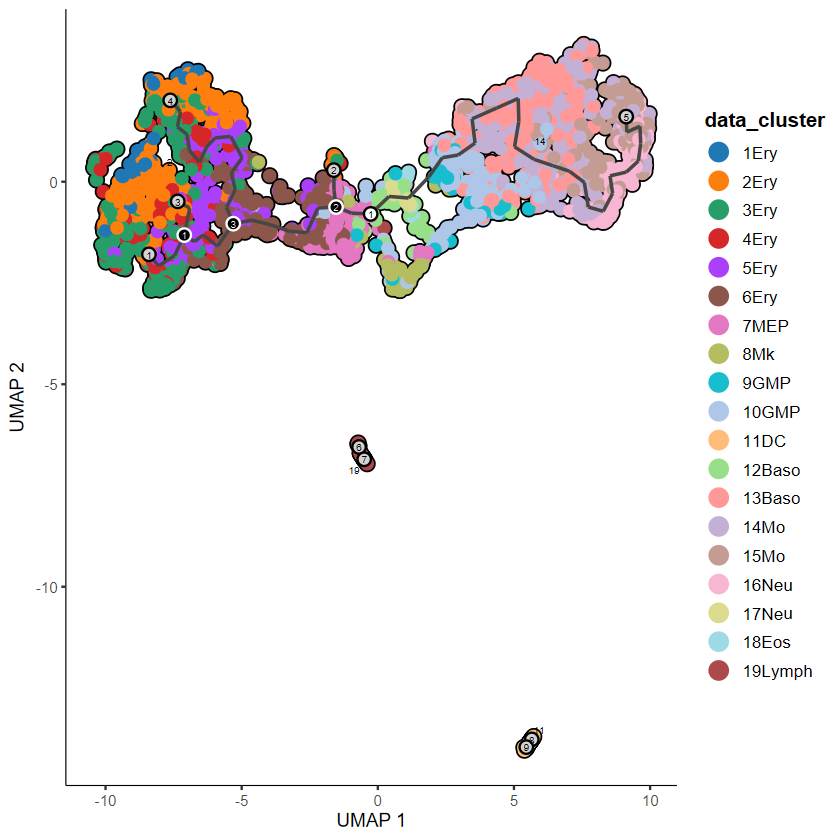

In [39]:
# Produce plot and add legend
p + scale_color_manual(values = custom_colors, name="Cluster", labels = cell_type_name) + theme(
  legend.position = "right",  # Ensure the legend is positioned
  legend.title = element_text(size = 12, face = "bold"),
  legend.text = element_text(size = 10)
)